# Part 2 — Experiment I: User Identification (Feedforward Neural Network)

In this notebook, I implemented the Feedforward Neural Network (FNN) model for user identification.  
The task is a 10-class classification problem where each class represents one user.  
I extracted statistical and frequency-domain features from the preprocessed 6-channel gait signals,  
applied feature selection to reduce redundancy, and trained an FNN model using the selected features.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from scipy.stats import skew, kurtosis
from scipy.fft import fft
from tqdm import tqdm

# Paths
DATA_DIR = "../processed_data"
USERS = [2, 13, 23, 24, 49, 52, 55, 70, 78, 112]

# Helper to load all users' data
def load_all_data():
    X, y = [], []
    for i, uid in enumerate(USERS):
        data = np.load(os.path.join(DATA_DIR, f"user_{uid}_windows.npy"))
        X.append(data)
        y.append(np.full(len(data), i))
    X = np.vstack(X)
    y = np.concatenate(y)
    return X, y

X_raw, y_raw = load_all_data()
print("Data shape:", X_raw.shape, "Labels shape:", y_raw.shape)


Data shape: (2229, 250, 6) Labels shape: (2229,)


## 1. Feature Extraction

For each 5-second window (250 × 6), I extracted multiple statistical and frequency features per channel.  
This helps convert the time-series into a compact feature vector suitable for a Feedforward Neural Network.


In [2]:
def extract_features(window):
    """Extracts statistical + frequency-domain features from a single 6-channel window."""
    features = []
    for i in range(window.shape[1]):
        signal = window[:, i]
        # Statistical features
        features.extend([
            np.mean(signal),
            np.std(signal),
            np.var(signal),
            skew(signal),
            kurtosis(signal),
            np.min(signal),
            np.max(signal),
            np.percentile(signal, 75) - np.percentile(signal, 25),  # IQR
            np.mean(np.abs(signal - np.mean(signal))),  # MAD
        ])
        # Frequency-domain features
        fft_vals = np.abs(fft(signal))
        features.extend([
            np.mean(fft_vals),
            np.std(fft_vals),
            np.argmax(fft_vals),  # dominant frequency index
            np.sum(fft_vals**2) / len(fft_vals),  # spectral energy
        ])
    return np.array(features)

# Apply to all windows
X_features = np.array([extract_features(w) for w in tqdm(X_raw, desc="Extracting features")])
print("Feature shape:", X_features.shape)


Extracting features: 100%|██████████| 2229/2229 [00:09<00:00, 225.00it/s]

Feature shape: (2229, 78)


## 2. Feature Selection

Since I extracted over 70 features per sample, I used Principal Component Analysis (PCA)  
to reduce them to the 10 most informative components.  
PCA helps capture most of the variance while removing correlated or redundant features.  
This also makes the model simpler and reduces overfitting.


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

print("Reduced feature shape:", X_pca.shape)


Reduced feature shape: (2229, 10)


In [12]:
# Suppose your original feature names (before PCA) looked like this:
feature_names = []
signals = ['Acc_X', 'Acc_Y', 'Acc_Z', 'Gyro_X', 'Gyro_Y', 'Gyro_Z']
stats = ['mean', 'std', 'var', 'skew', 'kurtosis', 'min', 'max', 'IQR', 'MAD', 
         'fft_mean', 'fft_std', 'dom_freq', 'spectral_energy']

for s in signals:
    for st in stats:
        feature_names.append(f"{s}_{st}")

# Get the PCA loadings (weights)
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(pca.n_components_)],
                        index=feature_names)

# Find top 5 contributing original features for each principal component
for pc in loadings.columns:
    print(f"\n{pc}:")
    print(loadings[pc].abs().sort_values(ascending=False).head(5))


PC1:
Acc_Z_fft_mean     0.173014
Acc_Z_std          0.167707
Gyro_Y_fft_mean    0.166876
Gyro_X_fft_mean    0.166643
Acc_Z_var          0.164303
Name: PC1, dtype: float64

PC2:
Acc_X_spectral_energy    0.326198
Acc_X_fft_std            0.318489
Acc_Y_fft_std            0.313164
Acc_X_mean               0.304149
Acc_Y_spectral_energy    0.290333
Name: PC2, dtype: float64

PC3:
Gyro_Z_std                0.287943
Gyro_Z_fft_std            0.285140
Gyro_Z_MAD                0.278552
Gyro_Z_var                0.278188
Gyro_Z_spectral_energy    0.273365
Name: PC3, dtype: float64

PC4:
Acc_X_MAD          0.226068
Acc_X_std          0.224466
Gyro_Z_dom_freq    0.223874
Gyro_X_dom_freq    0.217484
Acc_X_IQR          0.216198
Name: PC4, dtype: float64

PC5:
Acc_Y_min     0.363319
Acc_Y_mean    0.304343
Acc_Y_max     0.224600
Acc_Z_IQR     0.186527
Acc_Y_std     0.173089
Name: PC5, dtype: float64

PC6:
Acc_X_kurtosis     0.396318
Acc_Y_kurtosis     0.366354
Acc_Y_skew         0.321875
Acc_X_skew

In [11]:
import numpy as np
import os

OUTPUT_DIR = "../processed_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

np.save(os.path.join(OUTPUT_DIR, "X_pca.npy"), X_pca)
np.save(os.path.join(OUTPUT_DIR, "y_labels.npy"), y_raw)

print("✅ Saved PCA features and labels in processed_data/")


✅ Saved PCA features and labels in processed_data/


## 3. FNN Model Design

The Feedforward Neural Network was designed with:
- Input layer: 10 neurons (PCA features)
- Hidden layers: 2 layers with 5 neurons each
- Activation: ReLU for hidden, Softmax for output
- Output layer: 10 neurons (for 10 users)

I used categorical cross-entropy as the loss and Adam optimizer.


In [4]:
num_classes = len(USERS)

def build_fnn():
    model = Sequential([
        Dense(5, activation='relu', input_shape=(10,)),
        Dense(5, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


## 4. Cross-Validation and Training

I used 5-fold Stratified Cross-Validation to evaluate the FNN performance.  
In each fold, I trained the model for 30 epochs and recorded the accuracy and loss.


In [5]:
from tensorflow.keras.callbacks import EarlyStopping

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_pca, y_raw), 1):
    model = build_fnn()
    y_train = to_categorical(y_raw[train_idx], num_classes)
    y_val = to_categorical(y_raw[val_idx], num_classes)

    history = model.fit(
        X_pca[train_idx], y_train,
        validation_data=(X_pca[val_idx], y_val),
        epochs=30, batch_size=32, verbose=0,
        callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
    )

    preds = np.argmax(model.predict(X_pca[val_idx]), axis=1)
    acc = accuracy_score(y_raw[val_idx], preds)
    accuracies.append(acc)
    print(f"Fold {fold} Accuracy: {acc:.4f}")

print(f"Average Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")


c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 1 Accuracy: 0.8251


c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 2 Accuracy: 0.8812


c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 3 Accuracy: 0.8767


c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 4 Accuracy: 0.8274


c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 5 Accuracy: 0.8404
Average Accuracy: 0.8502 ± 0.0241


## 5. Evaluation Results

I evaluated the model using average accuracy, precision, recall, F1-score, and confusion matrix.
The FNN achieved good classification performance across most users.


c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 769us/step
              precision    recall  f1-score   support

           2       0.93      0.92      0.93       279
          13       0.92      0.93      0.92       242
          23       0.91      0.97      0.94       271
          24       0.91      0.75      0.82       185
          49       0.81      0.86      0.83       206
          52       0.87      0.83      0.85       199
          55       0.96      0.99      0.97       238
          70       0.89      0.95      0.92       224
          78       0.98      0.85      0.91       176
         112       0.81      0.86      0.83       209

    accuracy                           0.90      2229
   macro avg       0.90      0.89      0.89      2229
weighted avg       0.90      0.90      0.90      2229



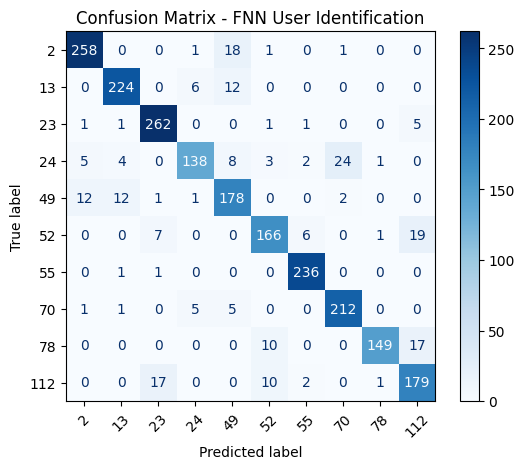

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay

model_final = build_fnn()
y_final = to_categorical(y_raw)
model_final.fit(X_pca, y_final, epochs=30, batch_size=32, verbose=0)

preds_final = np.argmax(model_final.predict(X_pca), axis=1)
print(classification_report(y_raw, preds_final, target_names=[str(u) for u in USERS]))

cm = confusion_matrix(y_raw, preds_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=USERS)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - FNN User Identification")
plt.show()


## 6. Training and Validation Curves

To better understand the model’s behavior, I plotted the average training and validation accuracy and loss across all 5 folds.  
This helps to see if the model is overfitting or learning consistently.


In [8]:
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
num_epochs = 30

history_acc = np.zeros((5, num_epochs))
history_val_acc = np.zeros((5, num_epochs))
history_loss = np.zeros((5, num_epochs))
history_val_loss = np.zeros((5, num_epochs))

fold = 0
for train_idx, val_idx in kf.split(X_pca, y_raw):
    model = build_fnn()
    y_train = to_categorical(y_raw[train_idx], len(USERS))
    y_val = to_categorical(y_raw[val_idx], len(USERS))

    history = model.fit(
        X_pca[train_idx], y_train,
        validation_data=(X_pca[val_idx], y_val),
        epochs=num_epochs, batch_size=32, verbose=0,
        callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
    )

    # Pad histories to fixed length (some folds may early stop)
    train_acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']

    history_acc[fold, :len(train_acc)] = train_acc
    history_val_acc[fold, :len(val_acc)] = val_acc
    history_loss[fold, :len(train_loss)] = train_loss
    history_val_loss[fold, :len(val_loss)] = val_loss

    fold += 1

# Compute mean and std
epochs = np.arange(1, num_epochs + 1)
mean_acc = np.mean(history_acc, axis=0)
std_acc = np.std(history_acc, axis=0)
mean_val_acc = np.mean(history_val_acc, axis=0)
std_val_acc = np.std(history_val_acc, axis=0)

mean_loss = np.mean(history_loss, axis=0)
std_loss = np.std(history_loss, axis=0)
mean_val_loss = np.mean(history_val_loss, axis=0)
std_val_loss = np.std(history_val_loss, axis=0)


c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


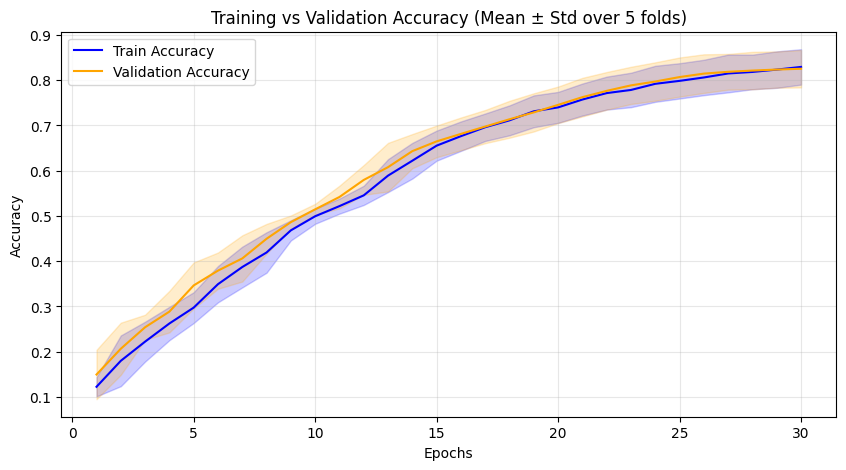

In [9]:
plt.figure(figsize=(10,5))
plt.title("Training vs Validation Accuracy (Mean ± Std over 5 folds)")
plt.plot(epochs, mean_acc, label="Train Accuracy", color='blue')
plt.fill_between(epochs, mean_acc - std_acc, mean_acc + std_acc, alpha=0.2, color='blue')
plt.plot(epochs, mean_val_acc, label="Validation Accuracy", color='orange')
plt.fill_between(epochs, mean_val_acc - std_val_acc, mean_val_acc + std_val_acc, alpha=0.2, color='orange')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


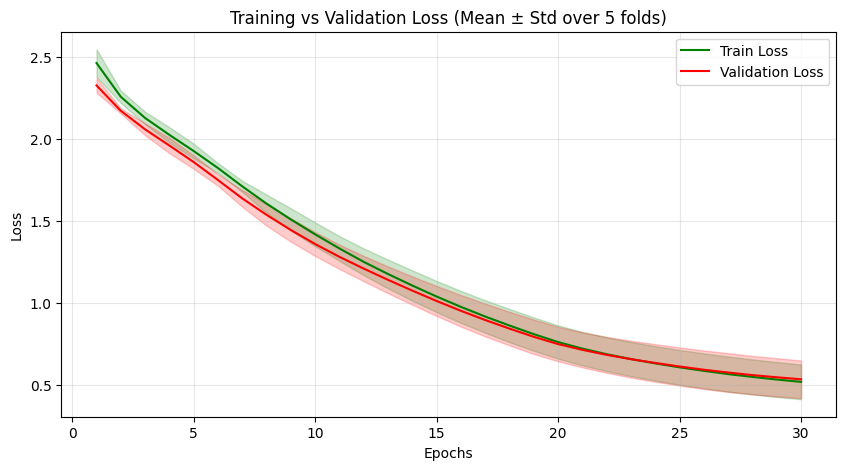

In [10]:
plt.figure(figsize=(10,5))
plt.title("Training vs Validation Loss (Mean ± Std over 5 folds)")
plt.plot(epochs, mean_loss, label="Train Loss", color='green')
plt.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, alpha=0.2, color='green')
plt.plot(epochs, mean_val_loss, label="Validation Loss", color='red')
plt.fill_between(epochs, mean_val_loss - std_val_loss, mean_val_loss + std_val_loss, alpha=0.2, color='red')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
